Basic settings

In [ ]:
from utgc.runner import EnsembleRunner
runner = EnsembleRunner.from_config('output/strict/testrun/config.yaml')

Election settings

In [ ]:
runner = (runner
    .add_election_updaters(
        years=[2016, 2020, 2024],
        elections=['PRE','GOV','ATG','AUD','TRE'],
        parties_to_columns_override={
            "2024GOV":{"R1":"G24GOVRHEN","R2":"G24GOVNCLA"}
        }
    )
    .add_election_aggregator(
        "sb1011_data",
        ["2016PRE", "2016GOV", "2016ATG", "2016AUD", "2016TRE", "2020PRE", "2020GOV", "2020ATG", "2024PRE", "2024GOV", "2024ATG", "2024AUD", "2024TRE"],
        parties=["D", "R", "-"]
    )
    .add_election_metric_updaters(
        "sb1011_data",
        ["partisan_bias_utah", "partisan_bias", "mean_median", "efficiency_gap", "stdev_partisan_share", "majority_partisan_shares", "majority_seats"]
    )
)

In [ ]:
# Set up visualization of sample maps
import os
import utgc.plotting as gcplt
import utgc.notebookhelper as nbh

munis, counties = nbh.load_boundaries_from_shapefiles()

runner = runner.add_runtime_callback(
    name="render_maps",
    frequency=10,
    action=lambda partition, step, output_dir: gcplt.visualize_partition(
        partition,
        step,
        os.path.join(output_dir, "maps"),
        counties=counties,
        municipalities=munis,
        split_munis_count=partition["split_muni"],
        split_counties_count=partition["split_county"],
    )
)

In [ ]:
runner = runner.precondition(steps=100)
runner.run(
    name="ensemble",
    output_dir="output/SA/",
    num_steps=500,
)

In [ ]:
import json

comparison_maps = {
    "Map C": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp"
    ),
    "Plaintiff 1": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-1/2025_USH_Plaintiff-1.shp"
    ),
    "Plaintiff 2": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-2/2025_USH_Plaintiff-2.shp"
    ),
    "2021 Enacted": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_Enacted/2021_USH_Enacted.shp"
    ),
    "UIRC Orange": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Orange/2021_USH_UIRC-Orange.shp"
    ),
    "UIRC Purple": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Purple/2021_USH_UIRC-Purple.shp"
    ),
    "UIRC Public": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Public/2021_USH_UIRC-Public.shp"
    ),
}

with open("output/SA/ensemble/comparison_maps.json", "w") as f:
    json.dump(comparison_maps, f, indent=2)

In [2]:
import json

if "comparison_maps" not in locals():
    with open("output/SA/ensemble/comparison_maps.json", "r") as f:
        comparison_maps = json.load(f)

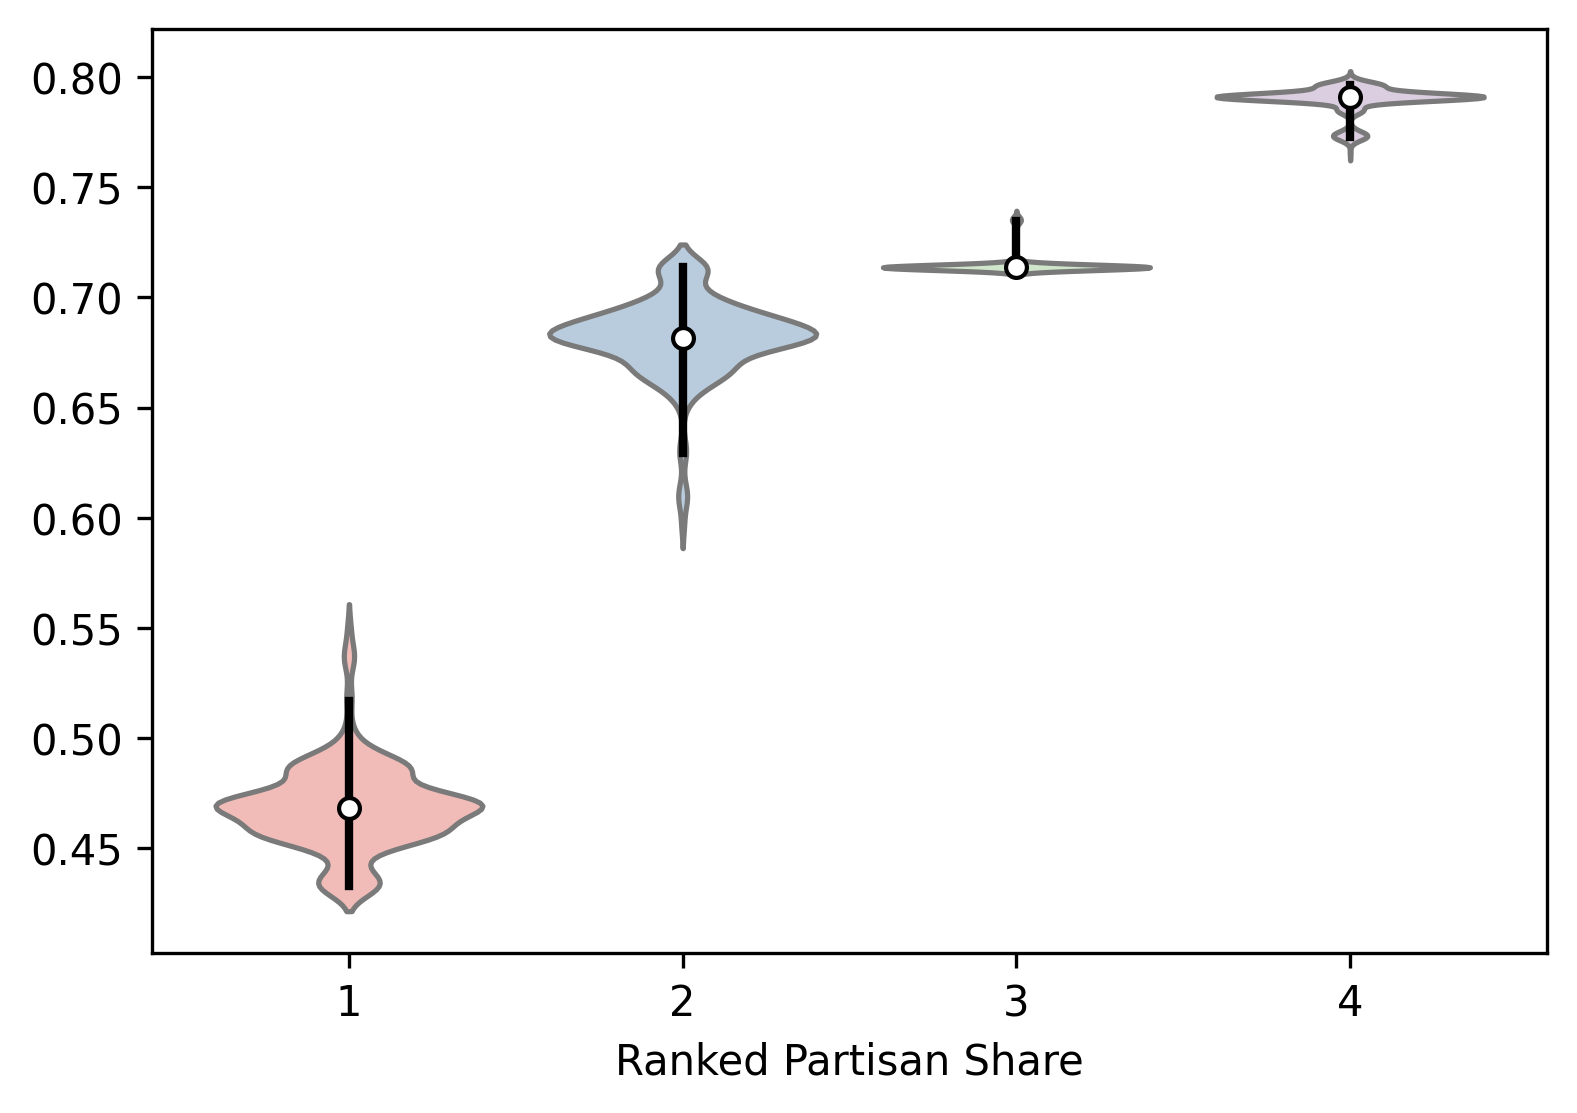

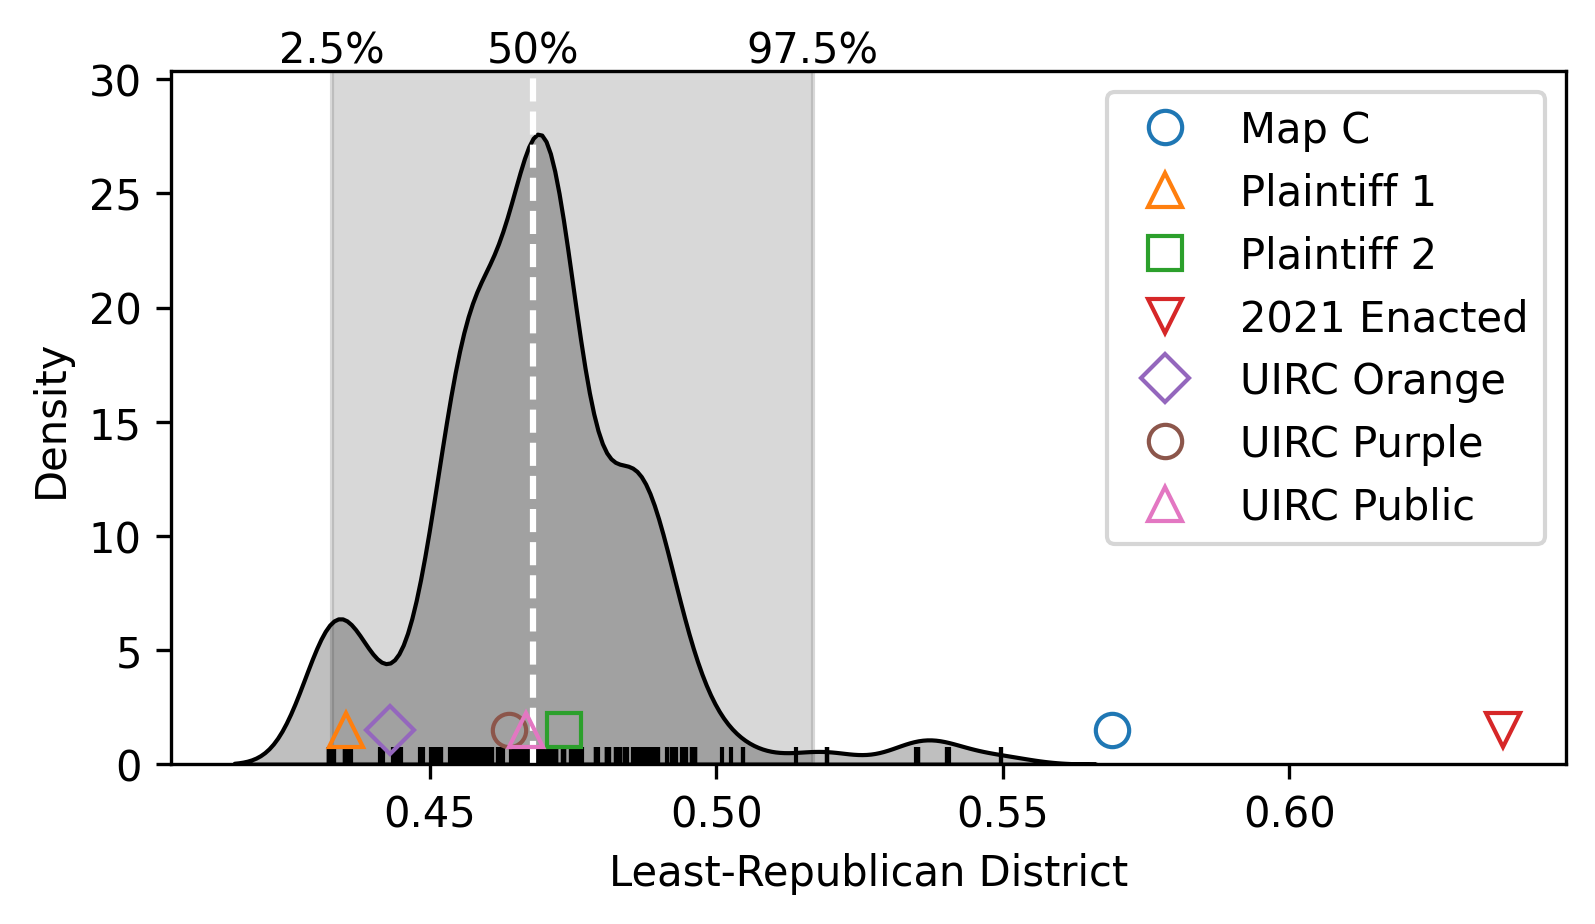

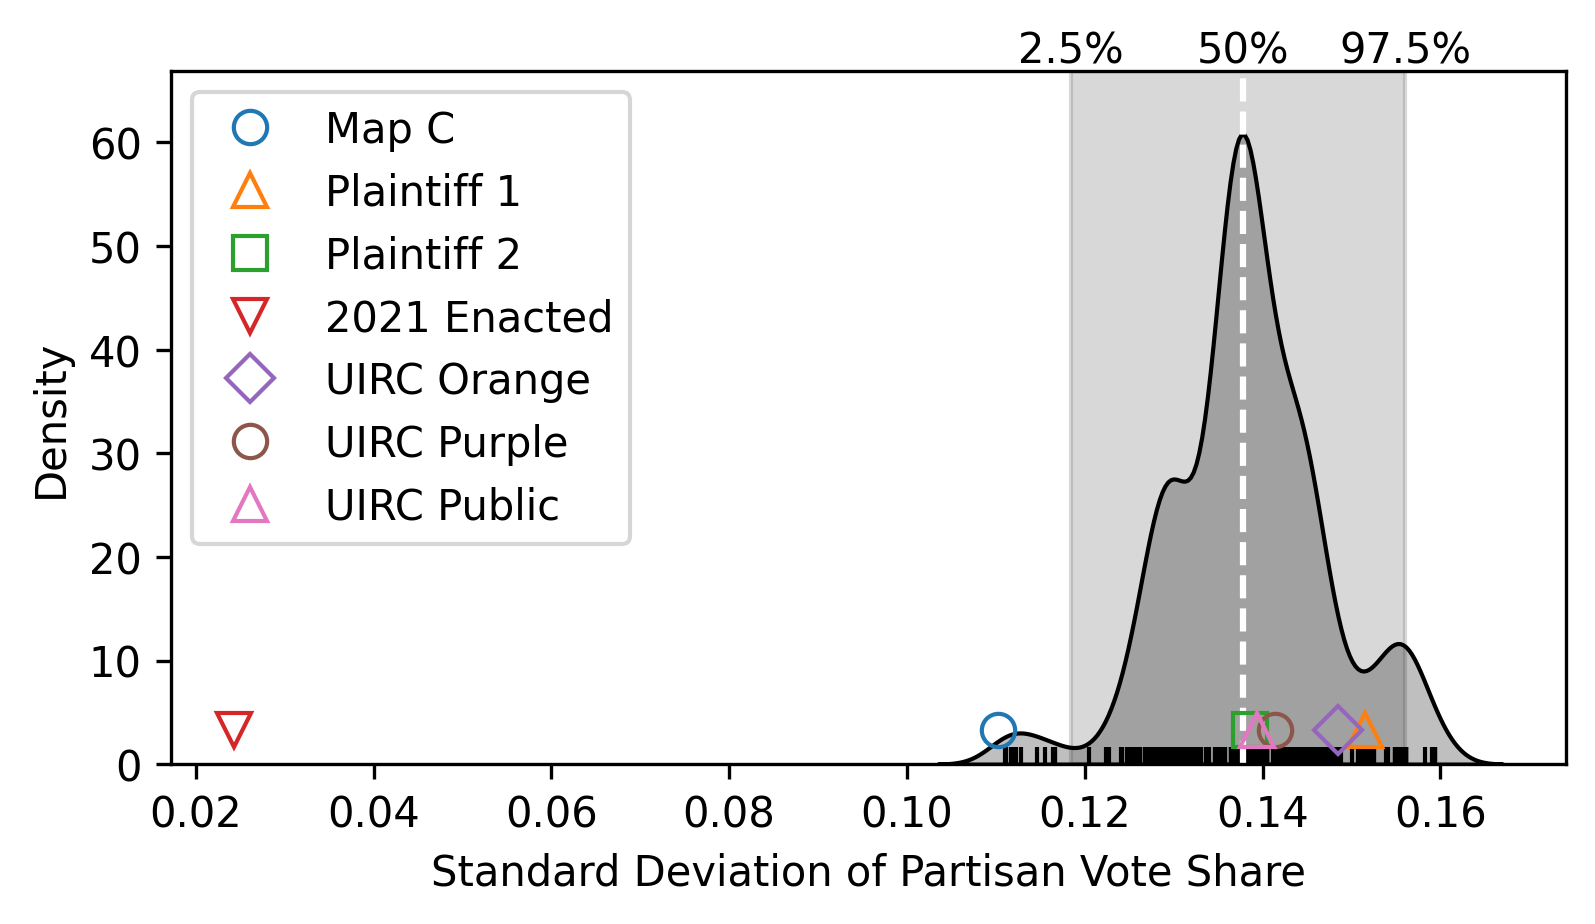

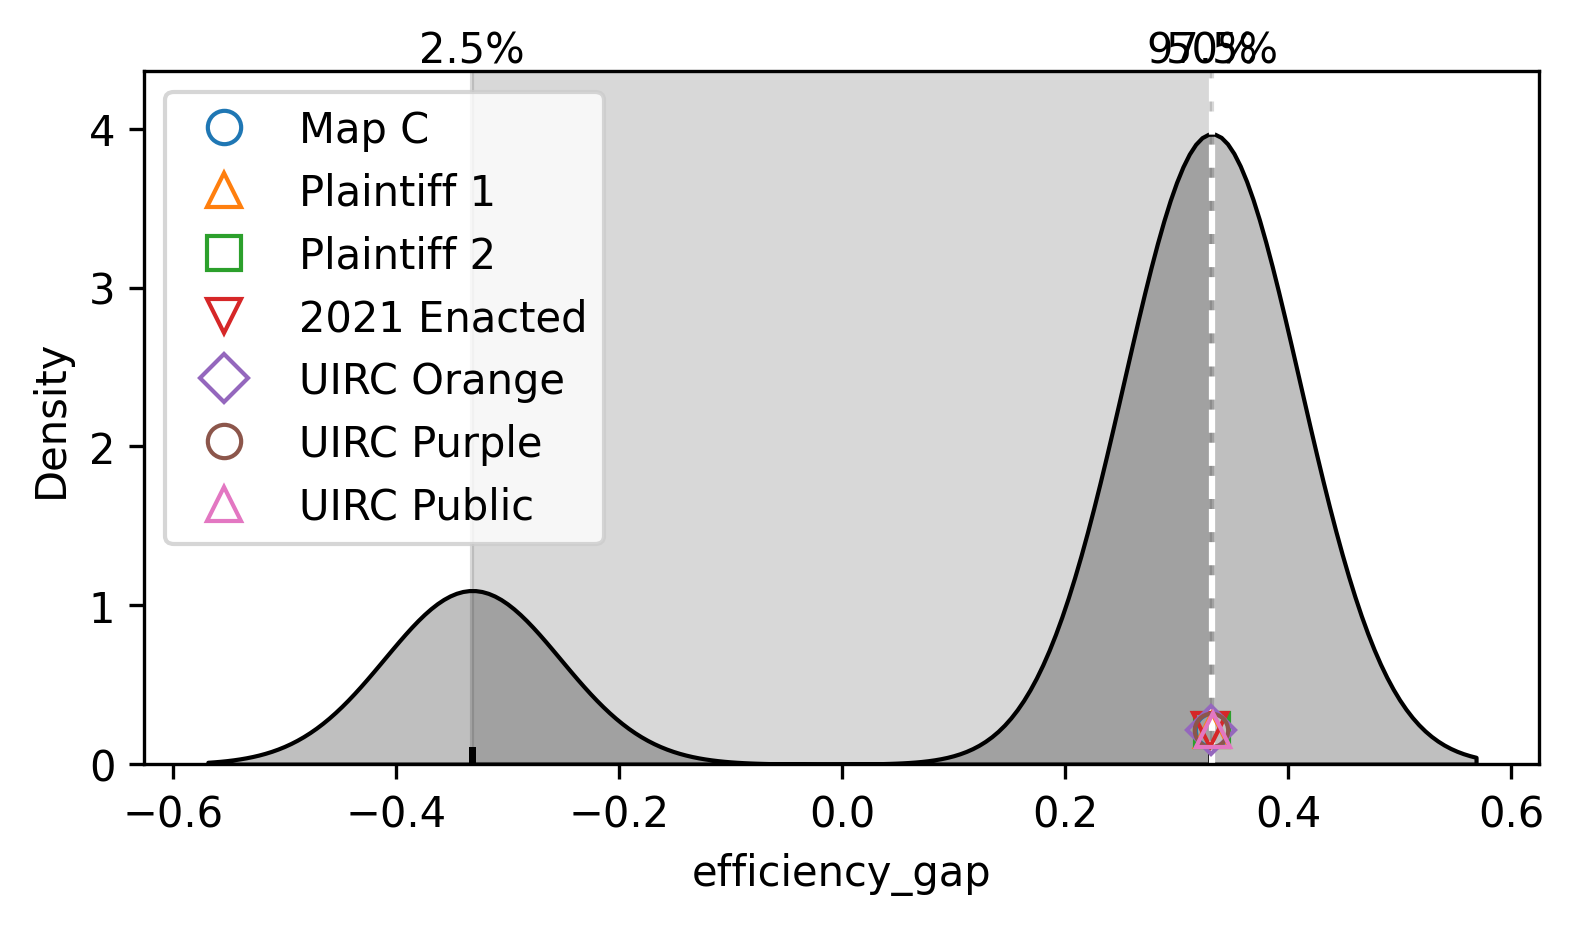

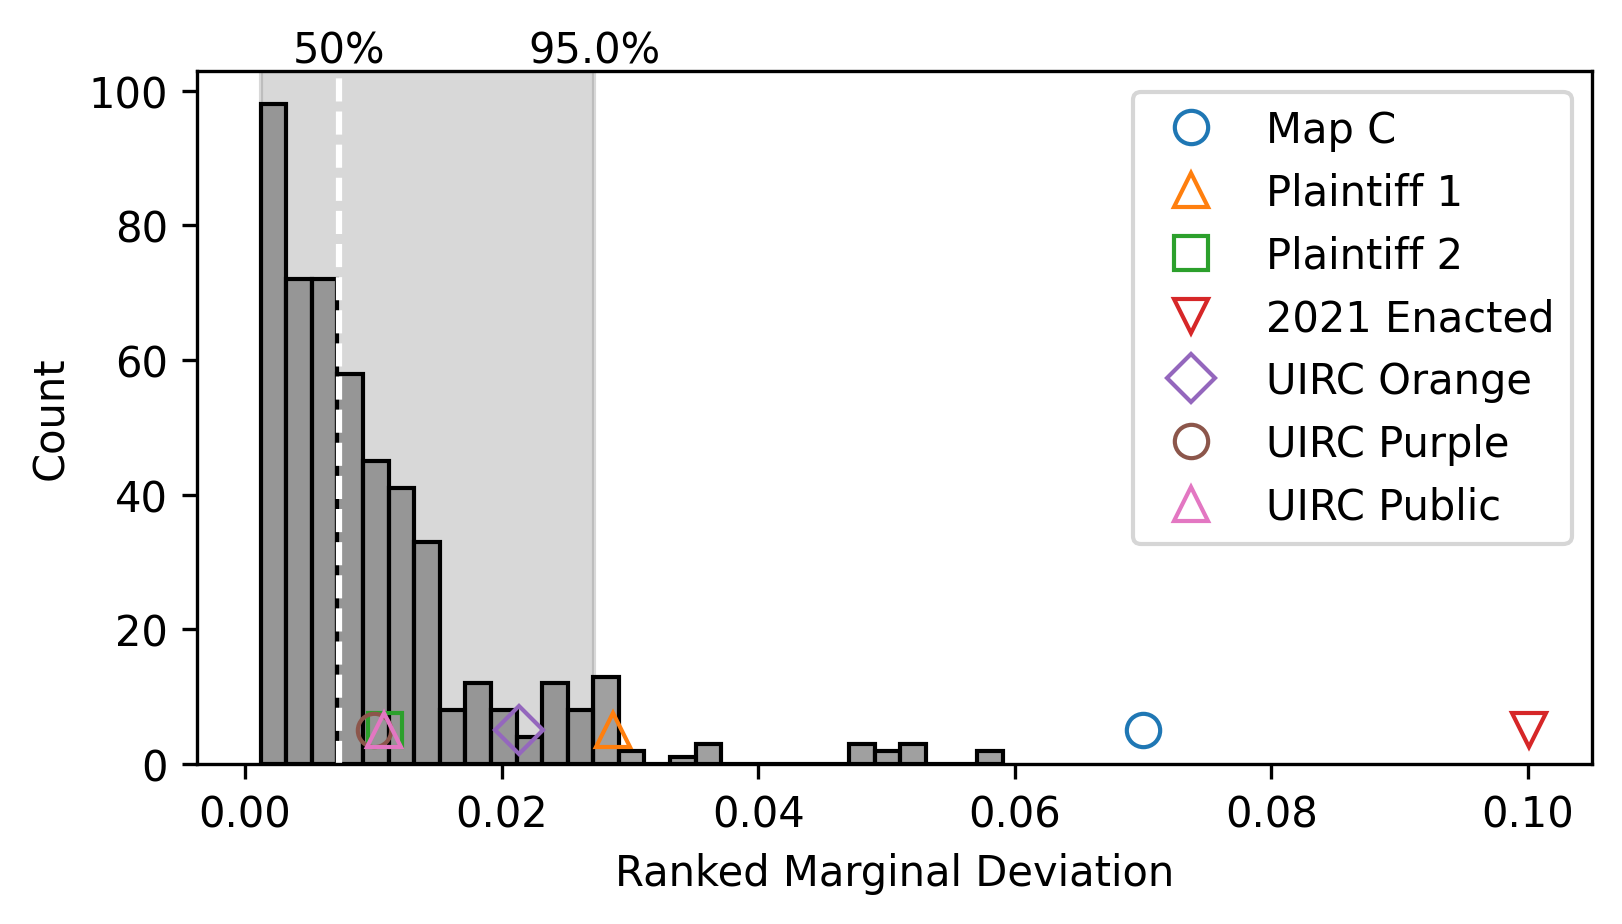

In [1]:
import utgc.results as gcres
import utgc.plotting as gcplt
import matplotlib.pyplot as plt

import json

if "comparison_maps" not in locals():
    with open("output/SA/ensemble/comparison_maps.json", "r") as f:
        comparison_maps = json.load(f)

# district_plot(
#     results,
#     "majority_partisan_shares",
#     reference_values={k: v["majority_partisan_shares"] for k, v in comparison_maps.items()},
#     relative_to_median=False
# )

output_path = "output/SA/ensemble/output.jsonl"

test = {
        mapname: min(stats["majority_partisan_shares"].values())
        for mapname, stats in comparison_maps.items()
    }

# splits = gcres.read_jsonl_table(output_path, ["split_muni", "split_county", "muni_multi_splits", "county_multi_splits"])
# splits.plot.hist(alpha=0.6, subplots=True, layout=(2, 2))
# plt.show()

# maj_seats = gcres.read_jsonl_table(output_path, "majority_seats")
# maj_seats.hist(alpha=0.6)
# plt.show()

party_shares = gcres.read_jsonl_table(output_path, "majority_partisan_shares")
party_shares = gcres.sort_subentries(party_shares, "majority_partisan_shares")

plt.figure(dpi=300, figsize=(6,4))
gcplt.district_plot(party_shares, relative_to_median=False)
plt.xlabel("Ranked Partisan Share")
plt.show()

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    party_shares["majority_partisan_shares_0"],
    reference_values={
        mapname: min(stats["majority_partisan_shares"].values())
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
    is_continuous=True
)
plt.xlabel("Least-Republican District")
plt.show()

sdvs = gcres.read_jsonl_table(output_path, "stdev_partisan_share")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    sdvs["stdev_partisan_share"],
    reference_values={
        mapname: stats["stdev_partisan_share"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
    is_continuous=True
)
plt.xlabel("Standard Deviation of Partisan Vote Share")
plt.show()

eg = gcres.read_jsonl_table(output_path, "efficiency_gap")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    eg["efficiency_gap"],
    reference_values={
        mapname: stats["efficiency_gap"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
    is_continuous=True
)
plt.show()

# leg_stats = gcres.read_jsonl_table(output_path, ["partisan_bias_utah","partisan_bias", "mean_median"])
# leg_stats.plot.hist(alpha=0.6, subplots=True, layout=(4,1))
# plt.show()

# court_stats = gcres.read_jsonl_table(output_path, ["efficiency_gap", "stdev_partisan_share"])
# court_stats["lrvs"] = maj_shares["majority_partisan_shares_0"]
# court_stats.plot.hist(alpha=0.6, subplots=True, layout=(3,1))
# plt.show()

ranked_means = party_shares.mean(axis=0)

def ranked_marginal_deviation(party_shares, ranked_means):
    rmd = ((party_shares - ranked_means) ** 2)
    if isinstance(party_shares, list):
        rmd = rmd.sum()
    else:
        rmd = rmd.sum(axis=1)
    return (rmd / len(ranked_means)) ** 0.5

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    ranked_marginal_deviation(party_shares, ranked_means),
    reference_values={
        mapname: ranked_marginal_deviation(
            sorted(stats["majority_partisan_shares"].values()),
            ranked_means
        ) for mapname, stats in comparison_maps.items()
    },
    highlight_interval=[0, 0.95],
    relative_to_median=False,
    is_continuous=False
)
plt.xlabel("Ranked Marginal Deviation")
plt.show()

In [27]:
hashes = gcres.read_jsonl_table(output_path, "assignment_hash")
print(f"Unique maps: {len(hashes.drop_duplicates()) / len(hashes):.1%}")

Unique maps: 100.0%
